# 06. ML / DL Baseline Comparison

## 목적

05에서 고정한 **Walk-forward Evaluation Protocol**을 그대로 유지한 채, 같은 문제와 같은 피처를 여러 모델에 적용합니다.

이 노트북의 질문은 하나입니다.

> **현재의 tabular 데이터에서 어떤 모델 계열이 가장 강한 baseline인가?**

### 비교 모델

- Naive: 현재 시즌 `goals`를 다음 시즌 예측값으로 그대로 사용
- ElasticNet
- Random Forest
- XGBoost
- CatBoost
- Baseline MLP

### 핵심 원칙

1. **Test(2024-25 → 2025-26)는 계속 잠급니다.**
2. Outer Walk-forward Fold는 05와 동일합니다.
3. 모든 모델은 같은 선수 행과 같은 Exp9Cb 정보만 사용합니다.
4. 전처리는 각 Outer Train에서만 fit합니다.
5. XGBoost / CatBoost / MLP의 학습 길이는 Outer Validation이 아니라 **Outer Train 내부의 Inner Validation**으로 결정합니다.
6. 이 단계에서는 본격적인 하이퍼파라미터 최적화를 하지 않습니다.
7. 결론은 자동으로 작성하지 않습니다.

## 0. 왜 지금 모델 비교를 하는가?

MLP를 먼저 많이 튜닝한 뒤 나중에 XGBoost/CatBoost가 더 강하다는 사실을 발견하면 실험 순서가 비효율적일 수 있습니다.

따라서 먼저 **합리적인 고정 설정의 여러 모델 계열**을 동일한 시간축 검증에서 비교합니다.

> 여기서 승리한 모델이 곧 최종 모델이라는 뜻은 아닙니다.  
> 어떤 모델 계열에 추가 튜닝 시간을 투자할 가치가 있는지 판단하는 단계입니다.

In [2]:
from pathlib import Path
import random
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


reset_seed()
print("Device:", DEVICE)

Device: cpu


## 1. 선택 라이브러리 확인

XGBoost와 CatBoost가 설치되어 있지 않아도 Notebook 전체가 즉시 중단되지는 않게 구성했습니다.

설치가 안 되어 있으면 아래 출력의 설치 명령을 실행한 뒤 **커널을 재시작하고 처음부터 다시 실행**하세요.

In [3]:
HAS_XGBOOST = True
HAS_CATBOOST = True

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    print("xgboost:", xgb.__version__)
except ImportError:
    HAS_XGBOOST = False
    print("[MISSING] xgboost")

try:
    import catboost
    from catboost import CatBoostRegressor
    print("catboost:", catboost.__version__)
except ImportError:
    HAS_CATBOOST = False
    print("[MISSING] catboost")

missing = []
if not HAS_XGBOOST:
    missing.append("xgboost")
if not HAS_CATBOOST:
    missing.append("catboost")

if missing:
    print("\n설치 예시:")
    print("pip install " + " ".join(missing))
    print("설치 후 Jupyter kernel을 재시작하세요.")

xgboost: 3.4.0
catboost: 1.2.10


## 2. 파일 경로 설정

06은 05 Notebook의 메모리 상태에 의존하지 않고 **새 커널에서도 단독 실행 가능**하도록 구성합니다.

필요 파일:

- long_basic Train
- long_basic Validation
- `team_season_stats_2000_2024.csv`
- `team_name_alias_map.csv`

**Test CSV는 로드하지 않습니다.**

In [4]:
# 자동 탐색이 실패할 때만 직접 지정
MANUAL_TRAIN_PATH = None
MANUAL_VALIDATION_PATH = None
MANUAL_TEAM_STATS_PATH = None
MANUAL_ALIAS_PATH = None

SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]
SEARCH_ROOTS = list(dict.fromkeys(p.resolve() for p in SEARCH_ROOTS if p.exists()))

LONG_BASIC_REQUIRED = {
    "player", "team", "league", "season", "target_season",
    "position_group", "age", "matched_next", "starts", "minutes",
    "goals", "assists", "non_penalty_goals", "penalty_goals",
    "penalty_attempts", "goals_per90", "assists_per90",
    "goal_contrib_per90", "next_goals"
}
ADVANCED_FORBIDDEN = {"xg", "xag", "shots", "progressive_carries"}


def read_header(path):
    try:
        return set(pd.read_csv(path, nrows=0).columns)
    except Exception:
        return set()


def find_csv_by_schema(kind):
    candidates = []

    for root in SEARCH_ROOTS:
        try:
            for path in root.rglob("*.csv"):
                if any(part.startswith(".") for part in path.parts):
                    continue

                cols = read_header(path)

                if kind in {"train", "validation"}:
                    if not LONG_BASIC_REQUIRED.issubset(cols):
                        continue
                    if ADVANCED_FORBIDDEN.intersection(cols):
                        continue

                    name = path.name.lower()
                    sample = pd.read_csv(path, usecols=["season"], nrows=50)
                    seasons = set(sample["season"].astype(str))

                    if kind == "train":
                        score = int("train" in name) + int("2000-2001" in seasons)
                    else:
                        score = int("validation" in name or "val" in name) + int("2023-2024" in seasons)

                    candidates.append((score, path))

                elif kind == "team_stats":
                    needed = {
                        "league", "season", "team_name", "team_rank_pct",
                        "team_points_per_game", "team_goal_diff_per_game"
                    }
                    if needed.issubset(cols):
                        candidates.append((2 if "team_season_stats" in path.name.lower() else 1, path))

                elif kind == "alias":
                    needed = {"player_data_team", "standings_team"}
                    if needed.issubset(cols):
                        candidates.append((2 if "alias" in path.name.lower() else 1, path))
        except (PermissionError, OSError):
            continue

    if not candidates:
        return None

    candidates.sort(key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return candidates[0][1]


def resolve_path(manual_path, kind):
    if manual_path is not None:
        path = Path(manual_path)
        if not path.exists():
            raise FileNotFoundError(f"지정한 경로가 없습니다: {path}")
        return path

    path = find_csv_by_schema(kind)
    if path is None:
        raise FileNotFoundError(
            f"{kind} 파일을 자동으로 찾지 못했습니다. MANUAL_*_PATH에 경로를 직접 지정하세요."
        )
    return path


TRAIN_PATH = resolve_path(MANUAL_TRAIN_PATH, "train")
VALIDATION_PATH = resolve_path(MANUAL_VALIDATION_PATH, "validation")
TEAM_STATS_PATH = resolve_path(MANUAL_TEAM_STATS_PATH, "team_stats")
ALIAS_PATH = resolve_path(MANUAL_ALIAS_PATH, "alias")

print("TRAIN      :", TRAIN_PATH)
print("VALIDATION :", VALIDATION_PATH)
print("TEAM STATS :", TEAM_STATS_PATH)
print("ALIAS      :", ALIAS_PATH)

TRAIN      : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\long_basic\train.csv
VALIDATION : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\long_basic\validation.csv
TEAM STATS : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\team_season_stats_2000_2024.csv
ALIAS      : D:\dev\03_PersonalProjects\next_season_goal_prediction\data\team_name_alias_map.csv


In [5]:
train_raw = pd.read_csv(TRAIN_PATH)
validation_raw = pd.read_csv(VALIDATION_PATH)
team_stats_raw = pd.read_csv(TEAM_STATS_PATH)
team_alias_raw = pd.read_csv(ALIAS_PATH)

for df in [train_raw, validation_raw, team_stats_raw, team_alias_raw]:
    drop_cols = [c for c in df.columns if c.lower().startswith("unnamed") or c == "index"]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)

print("Train shape      :", train_raw.shape)
print("Validation shape :", validation_raw.shape)
print("Train seasons    :", train_raw["season"].min(), "~", train_raw["season"].max())
print("Validation season:", validation_raw["season"].unique())
print("Advanced columns present:", sorted(ADVANCED_FORBIDDEN.intersection(train_raw.columns)))

Train shape      : (22430, 22)
Validation shape : (923, 22)
Train seasons    : 2000-2001 ~ 2022-2023
Validation season: <StringArray>
['2023-2024']
Length: 1, dtype: str
Advanced columns present: []


## 3. Test Lock

05와 동일하게 최종 Test를 잠급니다.

- Test input season: 2024-2025
- Test target season: 2025-2026

06의 어떤 모델도 이 시즌을 모델 선택에 사용하면 안 됩니다.

In [6]:
LOCKED_TEST_INPUT_SEASON = "2024-2025"
LOCKED_TEST_TARGET_SEASON = "2025-2026"

assert LOCKED_TEST_INPUT_SEASON not in set(train_raw["season"].astype(str))
assert LOCKED_TEST_INPUT_SEASON not in set(validation_raw["season"].astype(str))

print("Locked Test:", LOCKED_TEST_INPUT_SEASON, "→", LOCKED_TEST_TARGET_SEASON)
print("Test CSV is NOT loaded.")

Locked Test: 2024-2025 → 2025-2026
Test CSV is NOT loaded.


## 4. 개발 데이터 + Exp9Cb 피처 재생성

05와 동일하게:

- Train + 기존 Validation을 개발 데이터로 합침
- player별 과거 3시즌 scoring trend 생성
- 현재 시즌 자체는 rolling history에 포함하지 않음
- 팀 종합 성적 3개 merge
- Feature 생성 후 `matched_next=True`만 남김

In [7]:
dev_raw = pd.concat([train_raw, validation_raw], ignore_index=True).copy()
dev_raw["season_start"] = dev_raw["season"].astype(str).str[:4].astype(int)
dev_raw = dev_raw.sort_values(["player", "season_start"]).reset_index(drop=True)

player_group = dev_raw.groupby("player", sort=False)

dev_raw["goals_3yr_mean"] = player_group["goals"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
dev_raw["goals_per90_3yr_mean"] = player_group["goals_per90"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
dev_raw["goals_3yr_max"] = player_group["goals"].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]
dev_raw[HISTORICAL_COLS] = dev_raw[HISTORICAL_COLS].fillna(0.0)

print("Development rows:", len(dev_raw))
print("Season range:", dev_raw["season"].min(), "~", dev_raw["season"].max())

Development rows: 23353
Season range: 2000-2001 ~ 2023-2024


In [8]:
team_name_map = dict(zip(
    team_alias_raw["player_data_team"],
    team_alias_raw["standings_team"]
))
team_name_map.update({
    "Gladbach": "M'gladbach",
    "Luton Town": "Luton",
})

dev = dev_raw.copy()
dev["team_name"] = dev["team"].replace(team_name_map)

team_stats = team_stats_raw.copy()
if "position" in team_stats.columns and "team_rank" not in team_stats.columns:
    team_stats = team_stats.rename(columns={"position": "team_rank"})

TEAM_NUMERIC = [
    "team_rank_pct",
    "team_points_per_game",
    "team_goal_diff_per_game",
]

team_keep_cols = ["league", "season", "team_name"] + TEAM_NUMERIC
team_stats = team_stats[team_keep_cols].drop_duplicates(
    subset=["league", "season", "team_name"]
)

dev = dev.merge(
    team_stats,
    on=["league", "season", "team_name"],
    how="left",
    validate="many_to_one",
)

match_ratio = dev[TEAM_NUMERIC].notna().all(axis=1).mean()
print(f"Team feature match ratio: {match_ratio:.4%}")

if match_ratio <= 0.99:
    unmatched = dev.loc[
        dev[TEAM_NUMERIC].isna().any(axis=1),
        ["league", "season", "team", "team_name"]
    ].drop_duplicates()
    display(unmatched.head(30))

assert match_ratio > 0.99, "팀 성적 매칭률이 99% 이하입니다. alias를 확인하세요."

Team feature match ratio: 100.0000%


In [9]:
model_df = dev[dev["matched_next"] == True].copy()
model_df = model_df.sort_values(["season_start", "player"]).reset_index(drop=True)

BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

FINAL_NUMERIC = BASE_NUMERIC + HISTORICAL_COLS + TEAM_NUMERIC
FINAL_CATEGORICAL = ["league", "position_group"]
FEATURE_COLS = FINAL_NUMERIC + FINAL_CATEGORICAL
TARGET = "next_goals"

print("Conditional rows:", len(model_df))
print("Numeric count:", len(FINAL_NUMERIC))
print("Categorical:", FINAL_CATEGORICAL)
print("Season range:", model_df["season"].min(), "~", model_df["season"].max())

Conditional rows: 19403
Numeric count: 17
Categorical: ['league', 'position_group']
Season range: 2000-2001 ~ 2023-2024


## 5. Walk-forward Fold 고정

05와 동일한 4개 Outer Validation 시즌을 사용합니다.

각 Fold의 Outer Train 내부에서 가장 최근 시즌 하나를 Inner Validation으로 사용합니다.

- **Outer Validation:** 실제 모델 비교 점수
- **Inner Validation:** XGBoost/CatBoost/MLP의 학습 길이만 결정

In [10]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

fold_plan = []

for fold_id, outer_val_season in enumerate(OUTER_VAL_SEASONS, start=1):
    outer_val_start = int(outer_val_season[:4])
    outer_train_df = model_df[model_df["season_start"] < outer_val_start]
    outer_val_df = model_df[model_df["season_start"] == outer_val_start]

    inner_val_start = outer_train_df["season_start"].max()
    inner_val_df = outer_train_df[outer_train_df["season_start"] == inner_val_start]

    assert outer_train_df["season_start"].max() < outer_val_df["season_start"].min()

    fold_plan.append({
        "fold": fold_id,
        "inner_val_season": inner_val_df["season"].iloc[0],
        "outer_val_season": outer_val_season,
        "target_season": outer_val_df["target_season"].iloc[0],
        "outer_train_n": len(outer_train_df),
        "outer_val_n": len(outer_val_df),
    })

fold_plan_df = pd.DataFrame(fold_plan)
fold_plan_df

,fold,inner_val_season,outer_val_season,target_season,outer_train_n,outer_val_n
0,1,2019-2020,2020-2021,2021-2022,16284,834
1,2,2020-2021,2021-2022,2022-2023,17118,778
2,3,2021-2022,2022-2023,2023-2024,17896,738
3,4,2022-2023,2023-2024,2024-2025,18634,769


## 6. 공통 평가 지표

모든 모델에서 같은 지표를 기록합니다.

### 전체
- MAE
- RMSE
- R²
- Bias

### 고득점 구간
- 10+
- 15+
- 20+

고득점자 문제는 05에서 여러 시즌에 걸쳐 반복되었으므로 모델 비교에서도 반드시 같이 확인합니다.

In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "bias": float(np.mean(y_pred - y_true)),
    }


def high_scorer_metrics(y_true, y_pred, threshold):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true >= threshold

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "bias": np.nan,
            "actual_mean": np.nan,
            "pred_mean": np.nan,
        }

    return {
        "n": int(mask.sum()),
        "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        "bias": float(np.mean(y_pred[mask] - y_true[mask])),
        "actual_mean": float(np.mean(y_true[mask])),
        "pred_mean": float(np.mean(y_pred[mask])),
    }


def make_result_row(model_name, fold_id, outer_val_df, y_true, y_pred, fit_seconds, **extra):
    m = regression_metrics(y_true, y_pred)
    row = {
        "model": model_name,
        "fold": fold_id,
        "outer_val_season": outer_val_df["season"].iloc[0],
        "target_season": outer_val_df["target_season"].iloc[0],
        "train_n": extra.pop("train_n", np.nan),
        "val_n": len(outer_val_df),
        "fit_seconds": fit_seconds,
        **m,
        **extra,
    }

    for threshold in [10, 15, 20]:
        h = high_scorer_metrics(y_true, y_pred, threshold)
        row[f"{threshold}plus_n"] = h["n"]
        row[f"{threshold}plus_mae"] = h["mae"]
        row[f"{threshold}plus_bias"] = h["bias"]

    return row

## 7. 공통 Dense 전처리

ElasticNet / RandomForest / XGBoost / MLP에는 같은 `StandardScaler + OneHotEncoder` 표현을 사용합니다.

- scaling은 tree 모델에 필수는 아니지만 큰 문제를 만들지 않습니다.
- 이 단계에서는 estimator 자체의 baseline 성능을 비교하기 위해 공통 dense 표현을 유지합니다.
- CatBoost만 categorical 변수를 native 방식으로 처리합니다.

모든 전처리기는 Fold의 Train partition에서만 fit합니다.

In [12]:
def make_dense_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FINAL_NUMERIC),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                FINAL_CATEGORICAL,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def dense_fit_transform(train_df, eval_df):
    preprocessor = make_dense_preprocessor()
    X_train = preprocessor.fit_transform(train_df[FEATURE_COLS])
    X_eval = preprocessor.transform(eval_df[FEATURE_COLS])
    y_train = train_df[TARGET].to_numpy(dtype=np.float32)
    y_eval = eval_df[TARGET].to_numpy(dtype=np.float32)
    return X_train, X_eval, y_train, y_eval, preprocessor

## 8. ElasticNet / RandomForest 고정 Baseline

이 모델들은 06에서 하이퍼파라미터 탐색을 하지 않습니다.

설정은 **합리적인 고정 baseline**일 뿐 최적값이 아닙니다.

- ElasticNet: 선형 + L1/L2 규제
- RandomForest: 비선형 tree ensemble

이후 필요하면 강한 후보에만 별도 HPO를 적용합니다.

In [13]:
def fit_predict_elasticnet(outer_train_df, outer_val_df, seed):
    X_train, X_val, y_train, y_val, preprocessor = dense_fit_transform(
        outer_train_df, outer_val_df
    )

    model = ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=seed,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    elapsed = time.perf_counter() - start

    return y_val, pred, elapsed, {
        "input_dim": X_train.shape[1],
        "selected_rounds": np.nan,
    }


def fit_predict_random_forest(outer_train_df, outer_val_df, seed):
    X_train, X_val, y_train, y_val, preprocessor = dense_fit_transform(
        outer_train_df, outer_val_df
    )

    model = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=seed,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    elapsed = time.perf_counter() - start

    return y_val, pred, elapsed, {
        "input_dim": X_train.shape[1],
        "selected_rounds": np.nan,
    }

## 9. XGBoost — Inner Validation으로 boosting round 결정

Outer Validation을 early stopping에 사용하면 모델 선택 과정이 Outer Validation에 적응하게 됩니다.

따라서:

1. Outer Train의 마지막 시즌을 Inner Validation으로 사용
2. Inner Validation에서 `best_iteration` 선택
3. Outer Train 전체로 그 iteration 수만큼 다시 학습
4. Outer Validation은 마지막 평가에만 사용

06에서는 XGBoost의 다른 hyperparameter는 고정합니다.

In [14]:
def fit_predict_xgboost(outer_train_df, outer_val_df, seed):
    if not HAS_XGBOOST:
        raise RuntimeError("xgboost가 설치되어 있지 않습니다.")

    inner_val_start = outer_train_df["season_start"].max()
    inner_train_df = outer_train_df[outer_train_df["season_start"] < inner_val_start].copy()
    inner_val_df = outer_train_df[outer_train_df["season_start"] == inner_val_start].copy()

    X_inner_train, X_inner_val, y_inner_train, y_inner_val, _ = dense_fit_transform(
        inner_train_df, inner_val_df
    )

    selector = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        eval_metric="mae",
        early_stopping_rounds=50,
        random_state=seed,
        n_jobs=-1,
    )

    selector.fit(
        X_inner_train,
        y_inner_train,
        eval_set=[(X_inner_val, y_inner_val)],
        verbose=False,
    )

    best_iteration = getattr(selector, "best_iteration", None)
    if best_iteration is None:
        selected_rounds = 500
    else:
        selected_rounds = int(best_iteration) + 1

    X_train, X_val, y_train, y_val, _ = dense_fit_transform(
        outer_train_df, outer_val_df
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=selected_rounds,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        eval_metric="mae",
        random_state=seed,
        n_jobs=-1,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train, verbose=False)
    pred = model.predict(X_val)
    elapsed = time.perf_counter() - start

    return y_val, pred, elapsed, {
        "input_dim": X_train.shape[1],
        "selected_rounds": selected_rounds,
    }

## 10. CatBoost — categorical native 처리

CatBoost는 범주형 변수를 자체적으로 처리하는 것이 장점 중 하나이므로 여기서는 One-Hot을 강제하지 않습니다.

하지만 사용 정보는 동일합니다.

- 동일 numeric feature 17개
- `league`
- `position_group`

학습 iteration은 XGBoost와 마찬가지로 **Inner Validation**에서 결정합니다.

In [15]:
def prepare_catboost_xy(df):
    X = df[FEATURE_COLS].copy()

    for col in FINAL_CATEGORICAL:
        X[col] = X[col].fillna("__MISSING__").astype(str)

    y = df[TARGET].to_numpy(dtype=np.float32)
    cat_indices = [X.columns.get_loc(c) for c in FINAL_CATEGORICAL]
    return X, y, cat_indices


def fit_predict_catboost(outer_train_df, outer_val_df, seed):
    if not HAS_CATBOOST:
        raise RuntimeError("catboost가 설치되어 있지 않습니다.")

    inner_val_start = outer_train_df["season_start"].max()
    inner_train_df = outer_train_df[outer_train_df["season_start"] < inner_val_start].copy()
    inner_val_df = outer_train_df[outer_train_df["season_start"] == inner_val_start].copy()

    X_inner_train, y_inner_train, cat_indices = prepare_catboost_xy(inner_train_df)
    X_inner_val, y_inner_val, _ = prepare_catboost_xy(inner_val_df)

    selector = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        eval_metric="MAE",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
    )

    selector.fit(
        X_inner_train,
        y_inner_train,
        cat_features=cat_indices,
        eval_set=(X_inner_val, y_inner_val),
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False,
    )

    best_iteration = selector.get_best_iteration()
    selected_rounds = max(1, int(best_iteration) + 1)

    X_train, y_train, cat_indices = prepare_catboost_xy(outer_train_df)
    X_val, y_val, _ = prepare_catboost_xy(outer_val_df)

    model = CatBoostRegressor(
        iterations=selected_rounds,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
    )

    start = time.perf_counter()
    model.fit(
        X_train,
        y_train,
        cat_features=cat_indices,
        verbose=False,
    )
    pred = model.predict(X_val)
    elapsed = time.perf_counter() - start

    return y_val, pred, elapsed, {
        "input_dim": len(FEATURE_COLS),
        "selected_rounds": selected_rounds,
    }

## 11. Baseline MLP — 05 프로토콜 그대로

MLP는 05와 동일한 구조입니다.

- 64 → 32 → 1
- ReLU
- MSE
- Adam, lr=0.001
- batch=64

Inner Validation에서 best epoch를 선택한 뒤 Outer Train 전체로 그 epoch 수만큼 다시 학습합니다.

In [16]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X, y, batch_size=64, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def find_mlp_best_epoch(
    inner_train_df,
    inner_val_df,
    max_epochs=100,
    patience=10,
    lr=1e-3,
    batch_size=64,
    seed=SEED,
):
    reset_seed(seed)

    X_train, X_val, y_train, y_val, _ = dense_fit_transform(
        inner_train_df, inner_val_df
    )

    train_loader = make_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size, shuffle=False)

    model = BaselineMLP(X_train.shape[1]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    best_epoch = 1
    patience_count = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(X_b)
                loss = criterion(pred, y_b)
                val_loss_sum += loss.item() * len(X_b)

        val_loss = val_loss_sum / len(val_loader.dataset)

        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_epoch = epoch
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            break

    return best_epoch


def fit_predict_mlp(outer_train_df, outer_val_df, seed):
    inner_val_start = outer_train_df["season_start"].max()
    inner_train_df = outer_train_df[outer_train_df["season_start"] < inner_val_start].copy()
    inner_val_df = outer_train_df[outer_train_df["season_start"] == inner_val_start].copy()

    selected_epochs = find_mlp_best_epoch(
        inner_train_df,
        inner_val_df,
        max_epochs=100,
        patience=10,
        lr=1e-3,
        batch_size=64,
        seed=seed,
    )

    reset_seed(seed)
    X_train, X_val, y_train, y_val, _ = dense_fit_transform(
        outer_train_df, outer_val_df
    )

    train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)

    model = BaselineMLP(X_train.shape[1]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    start = time.perf_counter()
    for _ in range(selected_epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(
            torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy().ravel()

    elapsed = time.perf_counter() - start

    return y_val, pred, elapsed, {
        "input_dim": X_train.shape[1],
        "selected_rounds": selected_epochs,
    }

## 12. 모델 목록

여기서는 모델별로 다른 HPO를 하지 않습니다.

XGBoost 또는 CatBoost가 설치되지 않았다면 해당 모델은 자동으로 skip됩니다.

In [17]:
MODEL_RUNNERS = {
    "Naive_current_goals": None,
    "ElasticNet": fit_predict_elasticnet,
    "RandomForest": fit_predict_random_forest,
    "Baseline_MLP": fit_predict_mlp,
}

if HAS_XGBOOST:
    MODEL_RUNNERS["XGBoost"] = fit_predict_xgboost
if HAS_CATBOOST:
    MODEL_RUNNERS["CatBoost"] = fit_predict_catboost

print("Models to run:")
for name in MODEL_RUNNERS:
    print("-", name)

Models to run:
- Naive_current_goals
- ElasticNet
- RandomForest
- Baseline_MLP
- XGBoost
- CatBoost


## 13. Walk-forward Model Comparison 실행

실행량은 05보다 큽니다.

각 Fold에서 모든 모델이 **동일한 Outer Train / Outer Validation 행**을 사용합니다.

결과는:

- `model_fold_results`: Fold별 metric
- `model_fold_predictions`: 모든 Outer Validation 예측

에 저장됩니다.

In [18]:
fold_rows = []
prediction_frames = []

for fold_id, outer_val_season in enumerate(OUTER_VAL_SEASONS, start=1):
    outer_val_start = int(outer_val_season[:4])

    outer_train_df = model_df[
        model_df["season_start"] < outer_val_start
    ].copy()

    outer_val_df = model_df[
        model_df["season_start"] == outer_val_start
    ].copy()

    y_true_reference = outer_val_df[TARGET].to_numpy(dtype=float)

    print("\n" + "=" * 80)
    print(
        f"Fold {fold_id}: {outer_val_season} → "
        f"{outer_val_df['target_season'].iloc[0]} | "
        f"Train {len(outer_train_df):,} / Val {len(outer_val_df):,}"
    )
    print("=" * 80)

    # Naive
    naive_pred = outer_val_df["goals"].to_numpy(dtype=float)
    naive_row = make_result_row(
        "Naive_current_goals",
        fold_id,
        outer_val_df,
        y_true_reference,
        naive_pred,
        fit_seconds=0.0,
        train_n=len(outer_train_df),
        input_dim=1,
        selected_rounds=np.nan,
    )
    fold_rows.append(naive_row)

    naive_pred_df = outer_val_df[
        ["player", "team", "league", "season", "target_season", "position_group", "goals", "next_goals"]
    ].copy()
    naive_pred_df["fold"] = fold_id
    naive_pred_df["model"] = "Naive_current_goals"
    naive_pred_df["prediction"] = naive_pred
    prediction_frames.append(naive_pred_df)

    print(f"Naive_current_goals | MAE {naive_row['mae']:.4f}")

    # 학습 모델
    for model_idx, (model_name, runner) in enumerate(MODEL_RUNNERS.items(), start=1):
        if runner is None:
            continue

        seed = SEED + fold_id

        try:
            y_true, y_pred, fit_seconds, extra = runner(
                outer_train_df,
                outer_val_df,
                seed,
            )
        except Exception as exc:
            print(f"[FAILED] {model_name}: {type(exc).__name__}: {exc}")
            continue

        assert len(y_true) == len(outer_val_df)
        assert np.allclose(y_true, y_true_reference)

        row = make_result_row(
            model_name,
            fold_id,
            outer_val_df,
            y_true,
            y_pred,
            fit_seconds=fit_seconds,
            train_n=len(outer_train_df),
            **extra,
        )
        fold_rows.append(row)

        pred_df = outer_val_df[
            ["player", "team", "league", "season", "target_season", "position_group", "goals", "next_goals"]
        ].copy()
        pred_df["fold"] = fold_id
        pred_df["model"] = model_name
        pred_df["prediction"] = y_pred
        prediction_frames.append(pred_df)

        print(
            f"{model_name:<18} | "
            f"MAE {row['mae']:.4f} | "
            f"RMSE {row['rmse']:.4f} | "
            f"R² {row['r2']:.4f} | "
            f"10+ MAE {row['10plus_mae']:.4f} | "
            f"rounds/epochs {row['selected_rounds']} | "
            f"fit {fit_seconds:.1f}s"
        )

model_fold_results = pd.DataFrame(fold_rows)
model_fold_predictions = pd.concat(prediction_frames, ignore_index=True)

print("\nCompleted rows:", len(model_fold_results))


Fold 1: 2020-2021 → 2021-2022 | Train 16,284 / Val 834
Naive_current_goals | MAE 2.6295
ElasticNet         | MAE 2.3522 | RMSE 3.3121 | R² 0.4968 | 10+ MAE 5.7429 | rounds/epochs nan | fit 1.3s
RandomForest       | MAE 2.3579 | RMSE 3.3755 | R² 0.4774 | 10+ MAE 5.8290 | rounds/epochs nan | fit 3.0s
Baseline_MLP       | MAE 2.3835 | RMSE 3.3523 | R² 0.4845 | 10+ MAE 5.7167 | rounds/epochs 15 | fit 8.4s
XGBoost            | MAE 2.3568 | RMSE 3.3796 | R² 0.4761 | 10+ MAE 6.0596 | rounds/epochs 153 | fit 0.9s
CatBoost           | MAE 2.3295 | RMSE 3.3217 | R² 0.4939 | 10+ MAE 5.8569 | rounds/epochs 282 | fit 14.4s

Fold 2: 2021-2022 → 2022-2023 | Train 17,118 / Val 778
Naive_current_goals | MAE 2.9229
ElasticNet         | MAE 2.5216 | RMSE 3.5576 | R² 0.4002 | 10+ MAE 6.2470 | rounds/epochs nan | fit 1.4s
RandomForest       | MAE 2.5568 | RMSE 3.5802 | R² 0.3925 | 10+ MAE 6.4527 | rounds/epochs nan | fit 2.8s
Baseline_MLP       | MAE 2.5024 | RMSE 3.5452 | R² 0.4044 | 10+ MAE 6.2874 | rou

## 14. Fold별 결과

먼저 평균을 보기 전에 **각 시즌에서 모델 순위가 얼마나 바뀌는지** 확인합니다.

In [19]:
model_fold_results[
    [
        "model",
        "fold",
        "outer_val_season",
        "mae",
        "rmse",
        "r2",
        "bias",
        "10plus_mae",
        "10plus_bias",
        "selected_rounds",
        "fit_seconds",
    ]
].sort_values(["fold", "mae"])

,model,fold,outer_val_season,mae,rmse,r2,bias,10plus_mae,10plus_bias,selected_rounds,fit_seconds
5,CatBoost,1,2020-2021,2.329458,3.321748,0.493895,0.116386,5.856883,-5.334675,282.0,14.373742
1,ElasticNet,1,2020-2021,2.352171,3.312085,0.496835,0.139731,5.742904,-5.264454,NaN,1.272647
4,XGBoost,1,2020-2021,2.356782,3.379586,0.476117,0.068840,6.059583,-5.626899,153.0,0.881721
2,RandomForest,1,2020-2021,2.357885,3.375478,0.477390,0.168825,5.829011,-5.317173,NaN,2.982169
3,Baseline_MLP,1,2020-2021,2.383471,3.352308,0.484540,0.264577,5.716736,-5.161948,15.0,8.352849
0,Naive_current_goals,1,2020-2021,2.629496,3.910418,0.298620,0.715827,5.032609,-2.728261,NaN,0.000000
11,CatBoost,2,2021-2022,2.458012,3.461207,0.432252,0.201545,6.251170,-5.455955,378.0,19.415742
10,XGBoost,2,2021-2022,2.490295,3.493957,0.421457,0.166118,6.583165,-5.788401,116.0,0.613027
9,Baseline_MLP,2,2021-2022,2.502450,3.545215,0.404358,0.201957,6.287442,-5.662632,2.0,1.110089
7,ElasticNet,2,2021-2022,2.521614,3.557602,0.400188,0.254665,6.246982,-5.645360,NaN,1.391142


## 15. 모델별 Walk-forward 요약

단일 평균만 보지 않습니다.

- 평균
- 표준편차
- 최악 Fold
- 평균 학습 시간

을 같이 봅니다.

In [20]:
summary_rows = []

for model_name, g in model_fold_results.groupby("model"):
    row = {
        "model": model_name,
        "folds": g["fold"].nunique(),
        "mae_mean": g["mae"].mean(),
        "mae_std": g["mae"].std(ddof=1),
        "mae_worst": g["mae"].max(),
        "rmse_mean": g["rmse"].mean(),
        "rmse_std": g["rmse"].std(ddof=1),
        "rmse_worst": g["rmse"].max(),
        "r2_mean": g["r2"].mean(),
        "r2_std": g["r2"].std(ddof=1),
        "r2_worst": g["r2"].min(),
        "bias_mean": g["bias"].mean(),
        "10plus_mae_mean": g["10plus_mae"].mean(),
        "10plus_bias_mean": g["10plus_bias"].mean(),
        "15plus_mae_mean": g["15plus_mae"].mean(),
        "20plus_mae_mean": g["20plus_mae"].mean(),
        "fit_seconds_mean": g["fit_seconds"].mean(),
    }
    summary_rows.append(row)

model_summary = pd.DataFrame(summary_rows).sort_values("mae_mean").reset_index(drop=True)
model_summary

,model,folds,mae_mean,mae_std,mae_worst,rmse_mean,rmse_std,rmse_worst,r2_mean,r2_std,r2_worst,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,fit_seconds_mean
0,CatBoost,4,2.389375,0.079613,2.458075,3.405350,0.081179,3.487326,0.467967,0.027202,0.432252,0.080515,6.205128,-5.661766,8.319399,10.563598,16.812543
1,XGBoost,4,2.422982,0.068412,2.490295,3.452929,0.064618,3.518796,0.453072,0.023195,0.421457,0.055884,6.488239,-5.963394,8.738727,10.984545,0.856268
2,Baseline_MLP,4,2.427669,0.066870,2.502450,3.450454,0.098290,3.545215,0.453554,0.035705,0.404358,0.121606,6.200829,-5.789265,8.448502,10.836524,6.932175
3,ElasticNet,4,2.428893,0.083974,2.521614,3.441204,0.108962,3.557602,0.456292,0.040709,0.400188,0.106820,6.164765,-5.801749,8.436076,11.283875,1.369645
4,RandomForest,4,2.435000,0.088963,2.556759,3.459359,0.087555,3.580241,0.450508,0.039223,0.392530,0.134011,6.235227,-5.698726,8.408421,10.759566,2.928716
5,Naive_current_goals,4,2.780318,0.121878,2.922879,4.033013,0.180780,4.301910,0.251752,0.086593,0.122952,0.716864,5.609692,-3.343363,7.100250,8.277404,0.000000


## 16. MAE 기준 순위 시각화

에러바는 Fold 간 MAE 표준편차입니다.

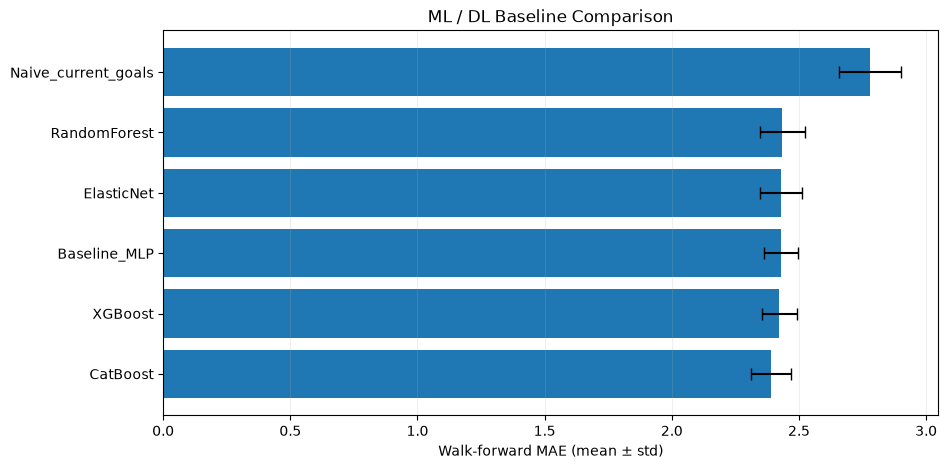

In [21]:
plot_df = model_summary.sort_values("mae_mean", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_df["model"],
    plot_df["mae_mean"],
    xerr=plot_df["mae_std"],
    capsize=4,
)
plt.xlabel("Walk-forward MAE (mean ± std)")
plt.title("ML / DL Baseline Comparison")
plt.grid(axis="x", alpha=0.2)
plt.show()

## 17. 시즌별 MAE Pivot

평균 1등 모델이 모든 시즌에서 1등인지 확인합니다.

In [22]:
mae_by_season = model_fold_results.pivot(
    index="outer_val_season",
    columns="model",
    values="mae",
)
mae_by_season

model,Baseline_MLP,CatBoost,ElasticNet,Naive_current_goals,RandomForest,XGBoost
outer_val_season,,,,,,
2020-2021,2.383471,2.329458,2.352171,2.629496,2.357885,2.356782
2021-2022,2.502450,2.458012,2.521614,2.922879,2.556759,2.490295
2022-2023,2.360409,2.311955,2.363695,2.757453,2.381253,2.371797
2023-2024,2.464347,2.458075,2.478091,2.811443,2.444102,2.473053


## 18. 고득점자 비교

05에서 확인한 핵심 실패 패턴이 모델 계열에 따라 줄어드는지 확인합니다.

특히:

- 전체 MAE는 비슷해도 10+/15+/20+가 다른 모델
- 전체 MAE는 좋지만 고득점 bias가 더 나쁜 모델

을 구분해야 합니다.

In [23]:
high_score_summary = model_summary[
    [
        "model",
        "mae_mean",
        "10plus_mae_mean",
        "10plus_bias_mean",
        "15plus_mae_mean",
        "20plus_mae_mean",
    ]
].copy()

high_score_summary

,model,mae_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean
0,CatBoost,2.389375,6.205128,-5.661766,8.319399,10.563598
1,XGBoost,2.422982,6.488239,-5.963394,8.738727,10.984545
2,Baseline_MLP,2.427669,6.200829,-5.789265,8.448502,10.836524
3,ElasticNet,2.428893,6.164765,-5.801749,8.436076,11.283875
4,RandomForest,2.435000,6.235227,-5.698726,8.408421,10.759566
5,Naive_current_goals,2.780318,5.609692,-3.343363,7.100250,8.277404


## 19. Fold별 모델 승자 확인

특정 모델이 한 시즌에서만 크게 좋아 평균을 끌어내린 것인지 확인합니다.

In [24]:
fold_winners = (
    model_fold_results
    .sort_values(["fold", "mae"])
    .groupby("fold", as_index=False)
    .first()[
        ["fold", "outer_val_season", "model", "mae", "rmse", "r2"]
    ]
)

fold_winners

,fold,outer_val_season,model,mae,rmse,r2
0,1,2020-2021,CatBoost,2.329458,3.321748,0.493895
1,2,2021-2022,CatBoost,2.458012,3.461207,0.432252
2,3,2022-2023,CatBoost,2.311955,3.351119,0.483447
3,4,2023-2024,RandomForest,2.444102,3.459091,0.470945


## 20. 시간축 OOF-like Prediction 확인

후속 Slice/Error Analysis에서 재사용할 수 있도록 모델별 Outer Validation prediction을 하나로 모았습니다.

In [25]:
print("Prediction rows:", len(model_fold_predictions))
print("Models:", sorted(model_fold_predictions["model"].unique()))
print("Seasons:", sorted(model_fold_predictions["season"].unique()))

model_fold_predictions.head()

Prediction rows: 18714
Models: ['Baseline_MLP', 'CatBoost', 'ElasticNet', 'Naive_current_goals', 'RandomForest', 'XGBoost']
Seasons: ['2020-2021', '2021-2022', '2022-2023', '2023-2024']


,player,team,league,season,target_season,position_group,goals,next_goals,fold,model,prediction
0,Aaron Ramsey,Juventus,Serie A,2020-2021,2021-2022,MF,2.0,0.0,1,Naive_current_goals,2.0
1,Abdoulaye Doucouré,Everton,Premier League,2020-2021,2021-2022,MF,2.0,2.0,1,Naive_current_goals,2.0
2,Abdoulaye Touré,Nantes,Ligue 1,2020-2021,2021-2022,MF,2.0,0.0,1,Naive_current_goals,2.0
3,Adam Lallana,Brighton,Premier League,2020-2021,2021-2022,FW,1.0,0.0,1,Naive_current_goals,1.0
4,Adam Ounas,Crotone,Serie A,2020-2021,2021-2022,FW,4.0,0.0,1,Naive_current_goals,4.0


## 21. 결과 저장

07 이후 Notebook에서 같은 결과를 재사용할 수 있도록 CSV로 저장합니다.

현재 작업 폴더 아래 `artifacts/`에 생성됩니다.

In [26]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

fold_result_path = ARTIFACT_DIR / "06_model_comparison_fold_results.csv"
summary_path = ARTIFACT_DIR / "06_model_comparison_summary.csv"
prediction_path = ARTIFACT_DIR / "06_model_comparison_predictions.csv"

model_fold_results.to_csv(fold_result_path, index=False)
model_summary.to_csv(summary_path, index=False)
model_fold_predictions.to_csv(prediction_path, index=False)

print("Saved:")
print("-", fold_result_path.resolve())
print("-", summary_path.resolve())
print("-", prediction_path.resolve())

Saved:
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\06_model_comparison_fold_results.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\06_model_comparison_summary.csv
- D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\06_model_comparison_predictions.csv


## 22. 06에서 고정한 비교 조건

후속 실험에서 모델 비교 규칙이 슬쩍 바뀌지 않도록 메타정보를 남깁니다.

In [27]:
BASELINE_COMPARISON_PROTOCOL = {
    "problem": "conditional_next_big5_goals_regression",
    "feature_set": "Exp9Cb",
    "outer_validation_seasons": OUTER_VAL_SEASONS,
    "outer_scheme": "expanding_window",
    "inner_validation": "latest season inside each outer train",
    "test_input_season": LOCKED_TEST_INPUT_SEASON,
    "test_target_season": LOCKED_TEST_TARGET_SEASON,
    "test_status": "LOCKED / NOT LOADED",
    "models": list(MODEL_RUNNERS.keys()),
    "primary_metric_for_ranking": "MAE mean",
    "secondary_metrics": [
        "MAE std",
        "worst-fold MAE",
        "RMSE",
        "R2",
        "10+/15+/20+ MAE",
        "high-scorer bias",
        "fit time",
    ],
    "hyperparameter_search": False,
}

BASELINE_COMPARISON_PROTOCOL

{'problem': 'conditional_next_big5_goals_regression',
 'feature_set': 'Exp9Cb',
 'outer_validation_seasons': ['2020-2021',
  '2021-2022',
  '2022-2023',
  '2023-2024'],
 'outer_scheme': 'expanding_window',
 'inner_validation': 'latest season inside each outer train',
 'test_input_season': '2024-2025',
 'test_target_season': '2025-2026',
 'test_status': 'LOCKED / NOT LOADED',
 'models': ['Naive_current_goals',
  'ElasticNet',
  'RandomForest',
  'Baseline_MLP',
  'XGBoost',
  'CatBoost'],
 'primary_metric_for_ranking': 'MAE mean',
 'secondary_metrics': ['MAE std',
  'worst-fold MAE',
  'RMSE',
  'R2',
  '10+/15+/20+ MAE',
  'high-scorer bias',
  'fit time'],
 'hyperparameter_search': False}

# 23. 결과 해석 — 직접 작성

아래는 **의도적으로 비워둡니다.**

## 확인할 질문

1. Naive baseline을 모든 학습 모델이 안정적으로 이기는가?
2. 평균 MAE가 가장 낮은 모델은 무엇인가?
3. Fold 간 MAE 표준편차가 가장 작은 모델은 무엇인가?
4. Worst Fold가 가장 안정적인 모델은 무엇인가?
5. 모델 순위가 시즌마다 크게 바뀌는가?
6. XGBoost / CatBoost가 MLP보다 강한가?
7. MLP를 추가로 Optuna 튜닝할 가치가 있는가?
8. ML 계열이 더 강하다면 해당 모델도 추후 HPO 대상에 포함해야 하는가?
9. 10+/15+/20+ 고득점 과소예측이 가장 적은 모델은 무엇인가?
10. 전체 MAE와 고득점 MAE 사이에 trade-off가 있는가?
11. 학습 시간 대비 성능까지 고려하면 어떤 모델이 실용적인가?

## 내 결론

- 평균 MAE 기준 1위:
- 안정성 기준:
- 고득점자 기준:
- 계산 비용 기준:
- MLP 추가 튜닝 필요성:
- ML 모델 추가 튜닝 필요성:
- 다음 단계에서 우선 검증할 후보:
- 추가 확인이 필요한 점:

## 다음 단계

06 결과를 본 뒤 07의 범위를 결정합니다.

### 기본 계획

**07. MLP Hyperparameter Optimization**

- Early Stopping을 각 Trial의 기본 학습 절차로 사용
- Walk-forward 평균 MAE를 목적함수로 사용
- architecture / dropout / learning rate / weight decay / batch size를 joint search

### 단, 06에서 XGBoost/CatBoost가 MLP를 크게 앞선다면

현업 관점에서는 MLP만 튜닝하는 것보다 **강한 ML 모델도 HPO 후보에 포함하는 방향으로 07을 수정**합니다.

즉 07의 상세 설계는 06 결과를 확인한 뒤 확정합니다.